# Extremist Message Classification with BERT

Fine-tunes `bert-base-uncased` to classify short text messages as EXTREMIST or NON_EXTREMIST, 
using the [Digital Extremism Detection Curated Dataset](https://www.kaggle.com/datasets/adityasureshgithub/digital-extremism-detection-curated-dataset).

**Approach:** clean the data → EDA → tokenize with BERT tokenizer → fine-tune for sequence classification → evaluate on a held-out validation split.

## 1. Load & Inspect Data


In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
df = pd.read_csv("/kaggle/input/datasets/adityasureshgithub/digital-extremism-detection-curated-dataset/dataset.csv")

In [3]:
df.head()

,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST


In [4]:
len(df)

3000

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Original_Message  3000 non-null   object
 1   Extremism_Label   2999 non-null   object
dtypes: object(2)
memory usage: 47.0+ KB


In [6]:
df.describe()

,Original_Message,Extremism_Label
count,3000,2999
unique,3000,2
top,grow up retard,NON_EXTREMIST
freq,1,1870


In [7]:
df.isna().sum()

Original_Message    0
Extremism_Label     1
dtype: int64

## 2. Data Cleaning
Drop rows with missing values before EDA.


In [8]:
df = df.dropna()

## 3. Exploratory Data Analysis
Class balance, message length, and vocabulary to understand the dataset before modeling.


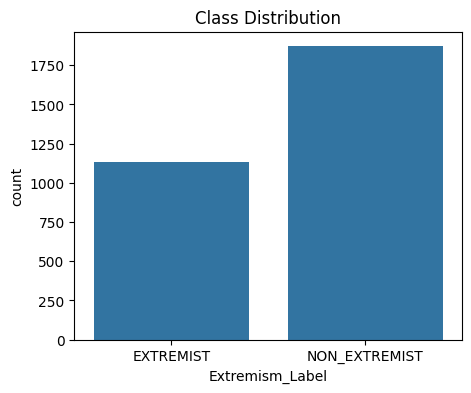

Extremism_Label
NON_EXTREMIST    0.623541
EXTREMIST        0.376459
Name: proportion, dtype: float64


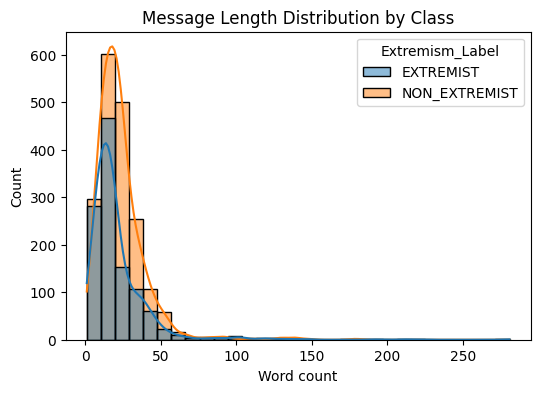

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class balance
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Extremism_Label")
plt.title("Class Distribution")
plt.show()
print(df["Extremism_Label"].value_counts(normalize=True))

# Message length distribution
df["msg_len"] = df["Original_Message"].str.split().apply(len)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="msg_len", hue="Extremism_Label", bins=30, kde=True)
plt.title("Message Length Distribution by Class")
plt.xlabel("Word count")
plt.show()

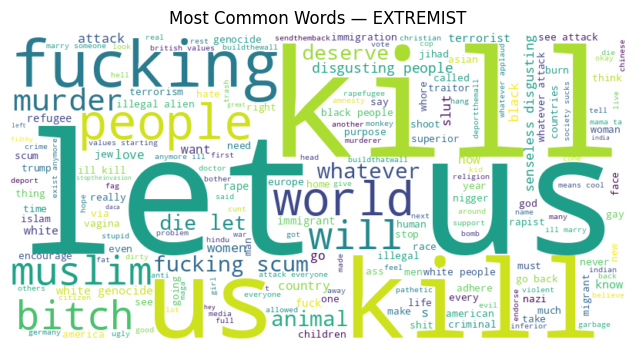

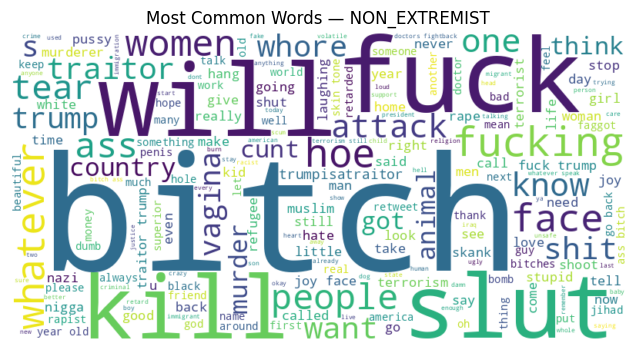

In [10]:
from wordcloud import WordCloud

for label in df["Extremism_Label"].unique():
    text = " ".join(df[df["Extremism_Label"] == label]["Original_Message"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Common Words — {label}")
    plt.show()

In [11]:
all_words = df["Original_Message"].str.cat(sep= " ").split()
unique_vocab = set(all_words)

In [12]:
print(f"Total tokens: {len(all_words)}")
print(f"Unique vocabulary size: {len(unique_vocab)}")

Total tokens: 67476
Unique vocabulary size: 7685


## 4. Fine-Tuning a Transformer Model
We use `GroNLP/hateBERT`, a BERT model further pre-trained on 1M+ posts from banned hateful/abusive Reddit communities. It consistently outperforms vanilla `bert-base-uncased` on hate/extremism-style classification tasks, which is why it's a stronger starting point than plain BERT for this dataset.


In [13]:
!pip install -q transformers datasets evaluate accelerate

import torch
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback, Trainer
from datasets import Dataset
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00


In [14]:
label_mapping = {"NON_EXTREMIST": 0, "EXTREMIST": 1}
df['label'] = df['Extremism_Label'].map(label_mapping)

df['Original_Message'] = df['Original_Message'].astype(str)
dataset = Dataset.from_pandas(df[['Original_Message', 'label']])

dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
val_dataset = dataset_split['test']

In [15]:
model_name = "GroNLP/hateBERT"
hf_tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
def tokenize_function(examples):
    return hf_tokenizer(
        examples["Original_Message"], 
        padding="max_length",   
        truncation=True,        
        max_length=128          
    )

In [17]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2399 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

### Class Imbalance Handling
The dataset is imbalanced (~62/38 non-extremist/extremist). We use a custom `WeightedTrainer` with class-weighted cross-entropy loss so the minority class isn't underweighted during training.


In [18]:
training_args = TrainingArguments(
    output_dir="./bert_extremism_results",
    eval_strategy="epoch",         
    save_strategy="epoch",         
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,         
    weight_decay=0.01,
    load_best_model_at_end=True,    
    metric_for_best_model="loss",   
    greater_is_better=False,       
    logging_steps=20,
    report_to="none"
)

In [19]:
import torch.nn as nn
from transformers import Trainer

class_counts = df['label'].value_counts().sort_index()
class_weights = torch.tensor(
    [len(df) / (2 * c) for c in class_counts], dtype=torch.float
).to("cuda" if torch.cuda.is_available() else "cpu")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=hf_tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.476887,0.428890,0.810000
2,0.316896,0.396125,0.828333
3,0.184510,0.419177,0.833333
4,0.139739,0.508732,0.841667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=300, training_loss=0.29056110223134357, metrics={'train_runtime': 145.9893, 'train_samples_per_second': 164.327, 'train_steps_per_second': 5.137, 'total_flos': 631203421808640.0, 'train_loss': 0.29056110223134357, 'epoch': 4.0})

In [20]:
model_name = "GroNLP/hateBERT" 
hf_tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 5. Evaluation
Classification report and confusion matrix on the held-out validation split.


               precision    recall  f1-score   support

NON_EXTREMIST       0.87      0.87      0.87       395
    EXTREMIST       0.75      0.75      0.75       205

     accuracy                           0.83       600
    macro avg       0.81      0.81      0.81       600
 weighted avg       0.83      0.83      0.83       600



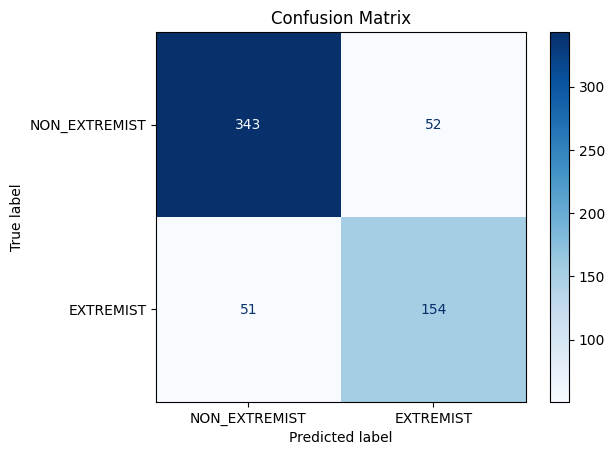

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

preds_output = trainer.predict(tokenized_val)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print(classification_report(y_true, y_pred, target_names=["NON_EXTREMIST", "EXTREMIST"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NON_EXTREMIST", "EXTREMIST"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 6. Training Curves


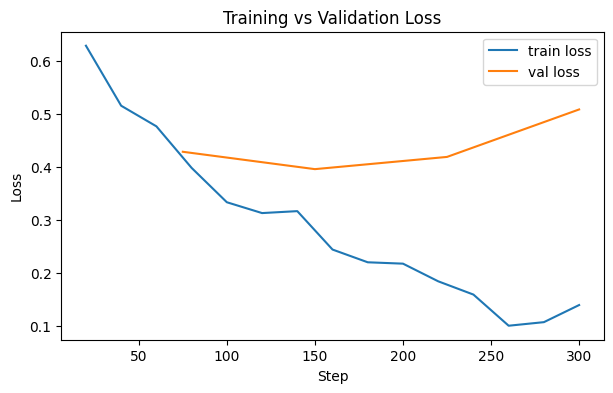

In [22]:
log_history = pd.DataFrame(trainer.state.log_history)
train_loss = log_history[log_history["loss"].notna()]
eval_loss = log_history[log_history["eval_loss"].notna()]

plt.figure(figsize=(7,4))
plt.plot(train_loss["step"], train_loss["loss"], label="train loss")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="val loss")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

## Takeaways
- Final validation accuracy / F1: *(fill in from classification_report above)*
- Class imbalance is ~62/38 non-extremist/extremist — addressed via class-weighted loss.
- Loss plateaued around epoch 4, consistent with early stopping triggering.

## Ideas to Push Accuracy Higher
- **Try alternate domain-adapted encoders**: `Hate-speech-CNERG/bert-base-uncased-hatexplain`, `facebook/roberta-hate-speech-dynabench-r4-target`, or `cardiffnlp` hate/offensive RoBERTa variants — swap `model_name` in the model cell and re-run.
- **Text cleaning**: strip URLs, mentions, and excess punctuation/emoji before tokenizing — noisy tokens can dilute signal.
- **Longer context**: bump `max_length` above 128 if messages are frequently truncated (check `msg_len` distribution from EDA).
- **Threshold tuning**: instead of argmax at 0.5, tune the decision threshold on the validation set using the precision-recall curve — often a quick recall/precision win on imbalanced data.
- **K-fold cross-validation**: single train/test split can be noisy at this dataset size; k-fold gives a more reliable accuracy estimate.
- **Ensembling**: average predicted probabilities across 2-3 differently-seeded fine-tunes or different base models.
- **More data / augmentation**: back-translation or paraphrasing minority-class examples to reduce imbalance further.
